# Importando Bibliotecas

In [1]:
# Seleção de diretórios
import os
try:
    # Configurando diretório de trabalho para 'aulas_teoricas'
    os.chdir('aulas_teoricas')
except FileNotFoundError:
    pass

# Carregamento de dados
from joblib import load, dump

# Processamento de dados
import pandas as pd
from util import utils as ut
import numpy as np

# Estatística
from scipy.stats import chi2_contingency

# Graficos
import seaborn as sns
import matplotlib.pyplot as plt

# Classificador
from src.regression import Regression

# Importando Dados

In [2]:
# Verificando os arquivos no diretório 'data/df_estruturada'
os.listdir("./data/df_estruturada")

['08_aula_09_X_test',
 '08_aula_09_X_train',
 '08_aula_09_X_valid',
 '08_aula_09_y_test',
 '08_aula_09_y_train',
 '08_aula_09_y_valid']

In [3]:
# Importando os dados de treino
df_train = pd.concat([
    load("./data/df_estruturada/08_aula_09_X_train"),
    load("./data/df_estruturada/08_aula_09_y_train")
], axis=1)
df_train.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe
541,0.060824,0.156681,2054.750574,416.256426,1.728509,0.274165,Alterado,imunodeficiencia
440,0.049927,0.277029,1853.437984,561.318387,1.240507,0.222972,Alterado,imunodeficiencia
482,0.020794,0.169621,3712.239299,1314.103239,1.470395,0.468595,Normal,leucemia
422,0.098734,0.117708,1864.705992,802.282545,1.574182,0.288605,Alterado,imunodeficiencia
778,0.193195,0.109547,2926.017038,1524.468444,2.400111,0.466135,Normal,leucemia


In [4]:
# Importando os dados de treino
df_valid = pd.concat([
    load("./data/df_estruturada/08_aula_09_X_valid"),
    load("./data/df_estruturada/08_aula_09_y_valid")
], axis=1)
df_valid.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe
904,0.205760,0.185144,1735.512581,778.451959,2.228345,0.117692,Alterado,imunodeficiencia
543,0.159611,0.161689,3612.217462,903.493773,2.271285,0.411603,Normal,leucemia
139,0.103551,0.147413,3488.419699,1593.807397,0.532531,0.439125,Normal,cancer
526,0.089775,0.154566,4379.204565,948.954431,1.394407,0.332721,Normal,cancer
868,0.175694,0.205065,3249.381189,1134.132464,0.468055,0.338485,Normal,cancer


In [5]:
# Importando os dados de treino
df_test = pd.concat([
    load("./data/df_estruturada/08_aula_09_X_test"),
    load("./data/df_estruturada/08_aula_09_y_test")
], axis=1)
df_test.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe
557,0.221689,0.237781,3107.839710,1065.934040,1.478703,0.419394,Normal,cancer
798,0.038133,0.239653,3744.296122,1055.014527,1.406982,0.337995,Normal,leucemia
977,0.233695,0.273088,3635.413739,1341.790170,2.114693,0.402492,Normal,cancer
136,0.247209,0.204334,3521.196455,1420.417680,1.050797,0.404243,Normal,cancer
575,0.040772,0.298275,2094.453959,537.993685,2.145163,0.134077,Alterado,imunodeficiencia


# Validação cruzada e busca de hiperparâmetros

## Treino

Iniciando o Grid Search com Cross Validation...
Total de variáveis originais pré-processadas: 9
Total de variáveis após VarianceThreshold:    9
Total de variáveis selecionadas no modelo:    9

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__CD3_2
3. num__CD8
4. num__PPD_log
5. num__correlatas
6. cat__FOXP3_Normal
7. cat__classe_cancer
8. cat__classe_imunodeficiencia
9. cat__classe_leucemia

--- Status de Cada Atributo no Pipeline ---
      Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
                   num__TP53              True               True
                  num__CD3_2              True               True
                    num__CD8              True               True
                num__PPD_log              True               True
             num__correlatas              True               True
           cat__FOXP3_Normal              True               True
          cat__classe_cancer              True               True
cat__classe_imunodef

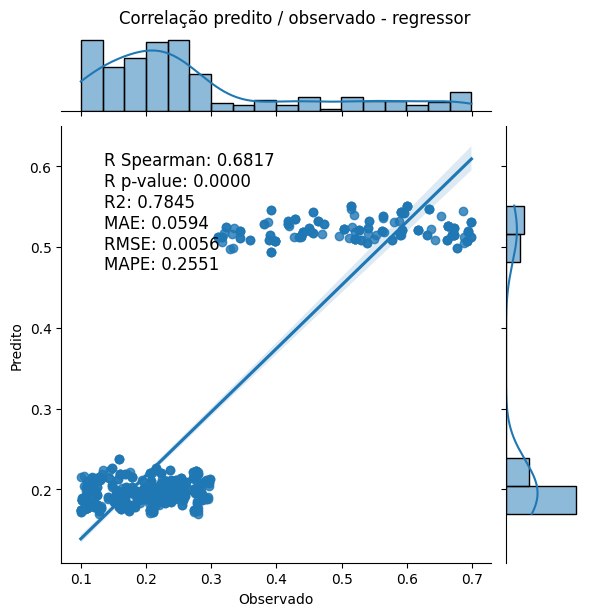

In [6]:
regressor = Regression(
    df=df_train
)

pred_lr = regressor.regress(modelo='regressor')

## Validação

## Teste

# Avalia Modelos